# PHYS3934: Computational Physics Assignment, 2026

# <span style="color:magenta">*Solutions*</span>

## Instructions
Provide written answers including explanations, where required, for all questions below. Questions that require writing or modifying existing code will include a subquestion asking you to provide a listing of the code. While code upload questions are not assigned marks directly, the code can be marked in combination with the questions that use the output of the code. Your provided code may be tested by markers: it should run without error and reproduce the outputs (e.g., figures) that you present in your assignment. While it is acceptable to discuss your assignment with other students, you must write your own version of each answer. For the coding component, this means the new working parts of the code needed for a problem must be your own work.

## The Dancing T-Handle

The video below shows a nice example of unstable motion of a dancing T-handle. You can watch a full video  [here](https://www.youtube.com/watch?v=1n-HMSCDYtM).  

In [2]:
from IPython.display import Video
Video("t-handle.mp4", embed=True)

This 'T-handle' is set spinning about a particular axis in zero gravity. The object spins for a while, and then flips its axis of rotation. The angular momentum of the T-handle is conserved, so after flipping, the handle is spinning in the opposite sense. The motion can be modelled using the Euler equations for free rotation of a rigid body (not to be confused with the Euler solver!):

$$A\frac{d\omega_{1}}{dt}=(B-C)\omega_{2}\omega_{3}  \tag{1}$$
$$B\frac{d\omega_{2}}{dt}=(C-A)\omega_{3}\omega_{1}  \tag{2}$$
$$C\frac{d\omega_{3}}{dt}=(A-B)\omega_{1}\omega_{2}  \tag{3}$$


where $\omega_{1}$, $\omega_{2}$, and $\omega_{3}$ are the angular velocities about the three principal axes of the body, and A, B, and C are the moments of inertia for rotation about those axes. The principal axes are fixed in the body, so Eqs (1)-(3) describe the motion in the moving frame of reference.

It is possible to show from these equations that for an object with three different principal moments of inertia, $A<B<C$, pure rotation about the axis corresponding to the "intermediate" moment of inertia, B, is unstable. This instability is exhibited by the T-handle. In this assignment, we will model the instability numerically.

### Question 1: Conserved Quantities and Non-Dimensionalisation (6 points)

**(a) [2 points]** The kinetic energy, K, and the magnitude of the angular momentum, L, of the body are given by:
$$K=\frac{1}{2}A\omega_{1}^{2}+\frac{1}{2}B\omega_{2}^{2}+\frac{1}{2}C\omega_{3}^{2}   \tag{4}$$
and
$$L^{2}=A^{2}\omega_{1}^{2}+B^{2}\omega_{2}^{2}+C^{2}\omega_{3}^{2}  \tag{5}$$
Using Eqs (1)-(3), show that K and L are conserved.


<span style="color:magenta">

## Solution:
    
To show that K and L are conserved, we must prove that their time derivatives are zero.
For Kinetic Energy ($K$):
$$\frac{dK}{dt} = A\omega_1\frac{d\omega_1}{dt} + B\omega_2\frac{d\omega_2}{dt} + C\omega_3\frac{d\omega_3}{dt}$$
Substitute the Euler equations:
$$\frac{dK}{dt} = \omega_1[(B-C)\omega_2\omega_3] + \omega_2[(C-A)\omega_3\omega_1] + \omega_3[(A-B)\omega_1\omega_2]$$
$$\frac{dK}{dt} = \omega_1\omega_2\omega_3 (B - C + C - A + A - B) = 0$$
Since $\frac{dK}{dt} = 0$, $K$ is conserved.

For Angular Momentum Squared ($L^2$):
$$\frac{d(L^2)}{dt} = 2A^2\omega_1\frac{d\omega_1}{dt} + 2B^2\omega_2\frac{d\omega_2}{dt} + 2C^2\omega_3\frac{d\omega_3}{dt}$$
Substitute the Euler equations:
$$\frac{d(L^2)}{dt} = 2A\omega_1[(B-C)\omega_2\omega_3] + 2B\omega_2[(C-A)\omega_3\omega_1] + 2C\omega_3[(A-B)\omega_1\omega_2]$$
$$\frac{d(L^2)}{dt} = 2\omega_1\omega_2\omega_3 (AB - AC + BC - AB + AC - BC) = 0$$
Since $\frac{d(L^2)}{dt} = 0$, $L$ is conserved.

## Marking notes:
- 2 points: correct logic using derivatives = 0 to prove that the quantities are conserved and correct derivations.
- 1.5 points: minor errors in derivation
- 1 point: logic correct, but significant errors in derivation
- 0.5 points: a reasonable attempt is made, but the logic is wrong
- 0 points: absent on ineligible submission
    </span>

**(b) [2 points]** By introducing a scale factor, $t_{s}$, for time, show that the Euler equations can be written in the non-dimensional form:
$$a\frac{d\overline{\omega}_{1}}{d\overline{t}}=(b-1)\overline{\omega}_{2}\overline{\omega}_{3}   \tag{6}$$
$$b\frac{d\overline{\omega}_{2}}{d\overline{t}}=(1-a)\overline{\omega}_{3}\overline{\omega}_{1}   \tag{7}$$
$$\frac{d\overline{\omega}_{3}}{d\overline{t}}=(a-b)\overline{\omega}_{1}\overline{\omega}_{2}   \tag{8}$$
where the bars denote dimensionless quantities, with $a=A/C$ and $b=B/C$.


<span style="color:magenta">

## Solution:

Let $t = t_s \overline{t}$ and $\omega_i = \overline{\omega}_i / t_s$. 
Then $\frac{d\omega_i}{dt} = \frac{d(\overline{\omega}_i / t_s)}{d(t_s \overline{t})} = \frac{1}{t_s^2} \frac{d\overline{\omega}_i}{d\overline{t}}$.
Substituting these into the third Euler equation:
$$C \left( \frac{1}{t_s^2} \frac{d\overline{\omega}_3}{d\overline{t}} \right) = (A-B) \left( \frac{\overline{\omega}_1}{t_s} \right) \left( \frac{\overline{\omega}_2}{t_s} \right)$$
Multiply both sides by $t_s^2 / C$:
$$\frac{d\overline{\omega}_3}{d\overline{t}} = \left( \frac{A}{C} - \frac{B}{C} \right) \overline{\omega}_1 \overline{\omega}_2 = (a-b)\overline{\omega}_1 \overline{\omega}_2$$
This matches the target equation. Following the same process for the first and second equations (and dividing by $C/t_s^2$) yields $a\frac{d\overline{\omega}_1}{d\overline{t}} = (b-1)\overline{\omega}_2\overline{\omega}_3$ and $b\frac{d\overline{\omega}_2}{d\overline{t}} = (1-a)\overline{\omega}_3\overline{\omega}_1$.    

## Marking Notes:
- 2 points: correct logic and workings using ts for both t and omega non-dimensionalisation.
- 1.5 points: minor errors in logic or workings. E.g., assuming an independent scaling factor for omega.
- 1 point: the logic is correct, but more significant issues with the workings
- 0.5 points: a reasonable attempt is made, but the logic is wrong
- 0 points: absent on ineligible submission


</span>


**(c) [2 points]** Show also that the conserved quantities may be rewritten in non-dimensional form as:
$$\overline{K}=\frac{1}{2}a\overline{\omega}_{1}^{2}+\frac{1}{2}b\overline{\omega}_{2}^{2}+\frac{1}{2}\overline{\omega}_{3}^{2}   \tag{9}$$
and
$$\overline{L}^{2}=a^{2}\overline{\omega}_{1}^{2}+b^{2}\overline{\omega}_{2}^{2}+\overline{\omega}_{3}^{2}   \tag{10}$$

**Important Note:** In the remaining questions, we will use the non-dimensional equations derived above, Eqs (6)-(10), but omit the bars.

<span style="color:magenta">

## Solution:
    
Substitute $\omega_i = \overline{\omega}_i / t_s$ into the original $K$ equation:
$$K = \frac{1}{2}A\left(\frac{\overline{\omega}_1}{t_s}\right)^2 + \frac{1}{2}B\left(\frac{\overline{\omega}_2}{t_s}\right)^2 + \frac{1}{2}C\left(\frac{\overline{\omega}_3}{t_s}\right)^2$$
Divide the entire equation by the scaling factor $C/t_s^2$ to define the non-dimensional kinetic energy $\overline{K}$:
$$\overline{K} = \frac{K t_s^2}{C} = \frac{1}{2}\left(\frac{A}{C}\right)\overline{\omega}_1^2 + \frac{1}{2}\left(\frac{B}{C}\right)\overline{\omega}_2^2 + \frac{1}{2}\left(\frac{C}{C}\right)\overline{\omega}_3^2 = \frac{1}{2}a\overline{\omega}_1^2 + \frac{1}{2}b\overline{\omega}_2^2 + \frac{1}{2}\overline{\omega}_3^2$$
Similarly for $L^2$, divide by $C^2/t_s^2$ to define $\overline{L}^2$:
$$\overline{L}^2 = \frac{L^2 t_s^2}{C^2} = \left(\frac{A}{C}\right)^2\overline{\omega}_1^2 + \left(\frac{B}{C}\right)^2\overline{\omega}_2^2 + \left(\frac{C}{C}\right)^2\overline{\omega}_3^2 = a^2\overline{\omega}_1^2 + b^2\overline{\omega}_2^2 + \overline{\omega}_3^2$$    

## Marking notes:
- 2 points: correct logic and workings. The error propagating from Q2 (e.g., assuming omega = omega_s*omega-bar) is not penalised here if already as is already accounted for in Q2.
- 1.5 points: correct logic, but minor issues with workings
- 1 point: some issues with logic or derivation, but the overall thinking in the right direction
- 0.5 points: a reasonable attempt is made, but the logic is wrong
- 0 points: absent on ineligible submission 
</span>

### Question 2: A Runge-Kutta Numerical Solution (10 points)
Consider a numerical solution of the non-dimensional Euler equations (6)-(8) using the fourth order Runge-Kutta (RK4) method.

**(a) [7 points]** Implement a right-hand side function to represent the coupled system of ODEs (6)-(8) and a main code which uses the right-hand side function to numerically solve the ODEs using RK4. Feel free to adapt code from Lecture 3 and Lab 3. Your code should use a non-dimensional time-step, $\tau=0.05$ and integrate for a total (non-dimensional) duration of 20, with $a=0.1$ and $b=0.5$. To display the results, your code should produce:
* A single plot showing $\omega_{1}$, $\omega_{2}$, and $\omega_{3}$ versus time; and
* A plot showing K versus time and L versus time (these two plots can be two panels in one figure.)

Apply your code to solve the following two initial-value problems: 
1. At $t=0$: $\omega_{1}=1.0$, $\omega_{2}=0.5$, $\omega_{3}=0.1.$
2. At $t=0$: $\omega_{1}=10^{-3}$, $\omega_{2}=2.0$, $\omega_{3}=0.0.$

One case should show stable oscillation and the other should show the instability demonstrated by the T-handle. Include your code and the plots it produces.


<span style="color:magenta">
    
## Marking Notes:

- 7 points: the code and all required figures are uploaded. In the code, RHS and RK4 are implemented as separate functions, and no major issues were observed. The plots for omega, K and L are correct for both cases 1 and 2, and are properly labelled and use correct units. Legends are included where required.
- Take off 4 points for missing code
- Take off 3 points for missing/incorrect plots (0.5 point each). If the plots are corr
- Take off 1 point for each: incorrect scaling of K and L plots, missing/incorrect labels, units, legend, issues or missing parts in the code (e.g, deriving rk4 for the system instead of using separate, more generic functions)

## Solution:
</span>

Running Case i...


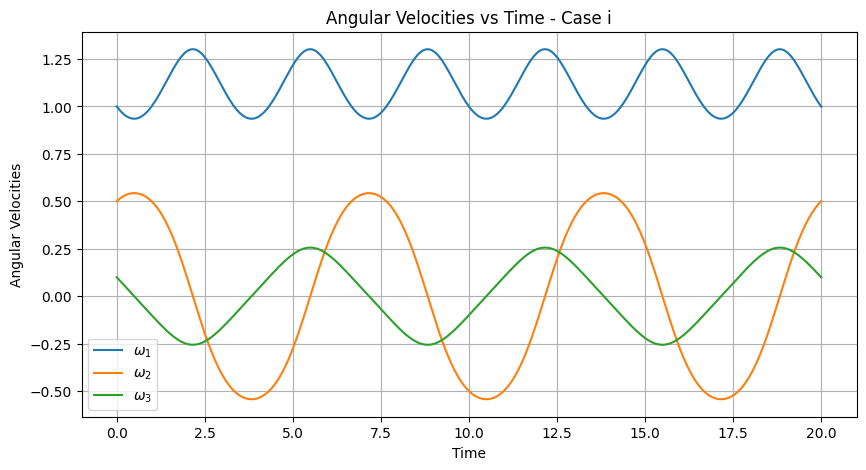

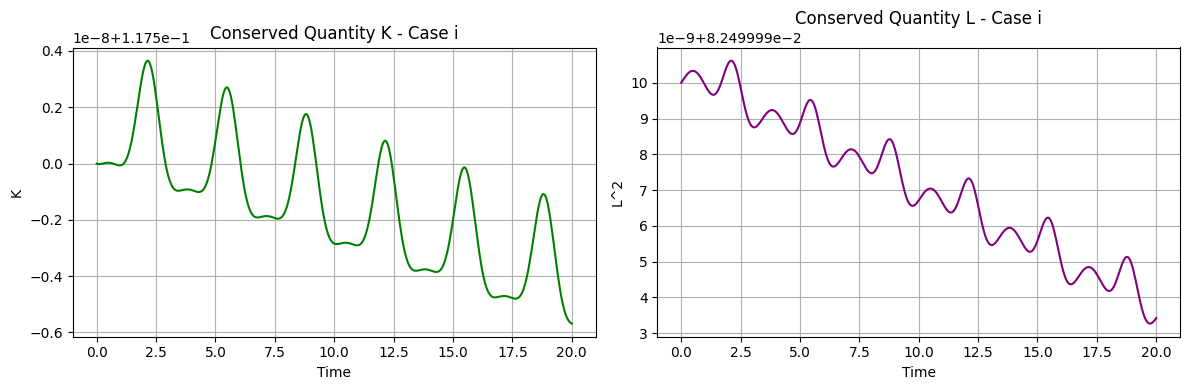

Running Case ii...


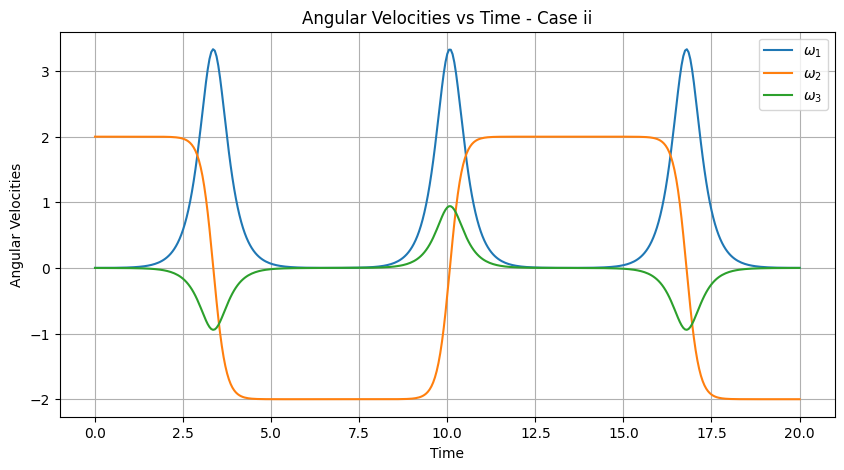

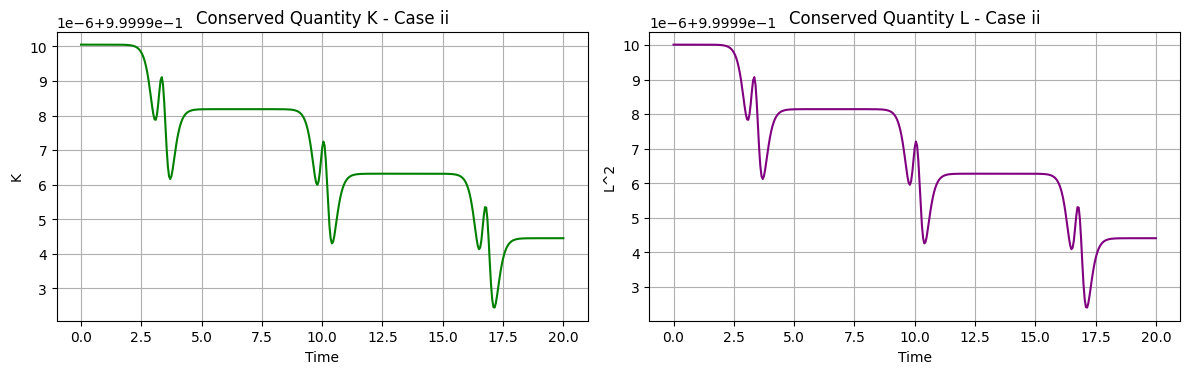

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rhs(t, w, a, b):
    """
    Right-hand side function for the coupled system of ODEs.
    Returns [dw1/dt, dw2/dt, dw3/dt]
    """
    w1, w2, w3 = w
    
    dw1_dt = ((b - 1) / a) * w2 * w3
    dw2_dt = ((1 - a) / b) * w3 * w1
    dw3_dt = (a - b) * w1 * w2
    
    return np.array([dw1_dt, dw2_dt, dw3_dt])

def rk4_step(f, t, w, dt, a, b):
    """
    Performs a single RK4 step.
    """
    k1 = f(t, w, a, b)
    k2 = f(t + dt/2, w + (dt/2)*k1, a, b)
    k3 = f(t + dt/2, w + (dt/2)*k2, a, b)
    k4 = f(t + dt, w + dt*k3, a, b)
    
    return w + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

def simulate_and_plot(w0, case_title):
    """
    Runs the simulation and generates the required plots.
    """
    # Parameters
    a = 0.1
    b = 0.5
    tau = 0.05  # time-step
    duration = 20.0
    num_steps = int(duration / tau)
    
    # Initialization
    t_vals = np.linspace(0, duration, num_steps + 1)
    w_vals = np.zeros((num_steps + 1, 3))
    w_vals[0] = w0
    
    # Time integration loop using RK4
    for i in range(num_steps):
        w_vals[i+1] = rk4_step(rhs, t_vals[i], w_vals[i], tau, a, b)
        
    w1 = w_vals[:, 0]
    w2 = w_vals[:, 1]
    w3 = w_vals[:, 2]
    
    # Calculate conserved quantities
    K = 1/2*(a * w1**2 + b * w2**2 + w3**2)
    L2 = a**2 * w1**2 + b**2 * w2**2 + w3**2
    
    # Plot 1: w1, w2, w3 versus time
    plt.figure(figsize=(10, 5))
    plt.plot(t_vals, w1, label=r'$\omega_1$')
    plt.plot(t_vals, w2, label=r'$\omega_2$')
    plt.plot(t_vals, w3, label=r'$\omega_3$')
    plt.xlabel('Time')
    plt.ylabel('Angular Velocities')
    plt.title(f'Angular Velocities vs Time - {case_title}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot 2: K and L versus time (two panels)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(t_vals, K, color='green')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('K')
    ax1.set_title(f'Conserved Quantity K - {case_title}')
    ax1.grid(True)
    
    # Adjust Y-axis limits slightly to show it's a flat line despite numerical noise
  #  k_mean = np.mean(K)
  #  ax1.set_ylim(k_mean * 0.99, k_mean * 1.01) 
    
    ax2.plot(t_vals, L2, color='purple')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('L^2')
    ax2.set_title(f'Conserved Quantity L - {case_title}')
    ax2.grid(True)
    
  #  l_mean = np.mean(L2)
  #  ax2.set_ylim(l_mean * 0.99, l_mean * 1.01)
    
    plt.tight_layout()
    plt.show()

# --- Run the Cases ---

# Case i
print("Running Case i...")
simulate_and_plot([1.0, 0.5, 0.1], "Case i")

# Case ii
print("Running Case ii...")
simulate_and_plot([1e-3, 2.0, 0.0], "Case ii")

**(b) [3 points]** Briefly explain:
1. Which case represents the flipping T-handle, and why.
2. How the solution matches what is seen in the video.
3. Whether your solutions are accurate.


<span style="color:magenta">

## Solution:
    
1. Case 2 represents the flipping T-handle. This is because the object is set spinning primarily about its intermediate axis ($\omega_2 = 2.0$), and the moments of inertia are defined by $a=0.1, b=0.5$, meaning $A < B < C$ ($0.1C < 0.5C < C$). Rotation about the intermediate axis is unstable.
2. In the generated plot for Case 2, $\omega_2$ remains constant for a while, then rapidly drops and flips to $-2.0$, before flipping back again. This perfectly mirrors the video where the object spins stably for a period, rapidly flips its axis 180 degrees, and continues spinning.
3. The solutions are both sufficiently accurate. We can verify this by looking at the plots for Kinetic Energy ($K$) and Angular Momentum ($L$). In both cases, the plotted $K$ and $L$ are nearly conserved, i.e., they change in a very narrow range on the order of $10^{-7}$ for the first case and $10^{-5}$ for the second. 


## Marking notes:
- 1 point per question: correct answer with an explanation.
- 0.5 per question: the logic is correct, but an explanation is missing or incorrect
- 0 points per question: an answer is missing or incorrect

</span>

### Question 3: 1-D Advection and Stability Analysis (9 points)

Consider the (non-dimensional) 1-D advection equation, which models the transport of a scalar quantity $a(x,t)$ in a medium flowing at a constant velocity $c_0$:
$$ \frac{\partial a}{\partial t} =  -c_0 \frac{\partial a}{\partial x}. \tag{11} $$

The function $$a(x,t)=f(x-c_0t), \tag{12} $$
provides a solution to Eq. (11) for the general initial value problem, where $$f(x)=a(x,0)$$ is the initial amplitude profile.

**(a) [3 points]** For the initial profile 

$$
a(x,0) = A \exp \left[-\kappa\left(x-\frac{1}{2}\right)^2\right]
\tag{13}
$$

where $A$ and $\kappa$ are constants. Sketch the profile $a(x,t)$ at time $t=0$ and at a time $t>0$.


<span style="color:magenta">

## Solution
![Q3a answer](Q3a.jpeg)

## Marking notes:
- 3 points: correct Gaussian profile at $t=0$ with maximum at $A$ and centred at $x=1/2$; shows movement to right at $t>0$ to a point $x=1/2+c_0t$. Labels and legends are provided.
- 1.5 points: the profiles are correct, but the labels for their position and max values are missing.
- Take 1 point off  for each: incorrect profile or position, missing axies and other labels

</span>



**(b) [6 points]** Consider the numerical solution of Eq. (11) with the "leap-frog” scheme

$$
a_j^{\,n+1} = a_j^{\,n-1} - g\left(a_{j+1}^{\,n}-a_{j-1}^{\,n}\right),
\tag{14}
$$

where

$$
g = \frac{c_0 \tau}{h}.
$$

1. Apply von Neumann stability analysis to Eq. (14) and show that the amplification factor is

$$
\xi = - i g \sin(kh) \pm \sqrt{1 - g^2 \sin^2(kh)}.
\tag{15}
$$

You will need to solve a quadratic equation.

2.  Determine when the leap-frog scheme, Eq. (14), is unstable.

<span style="color:magenta"> 

## Solution b1
    
Consider trial solution, $ a_j^n = A^n e^{ikjh} $, for a complex wave solution with wavenumber \(k\).

Substituting into equation (14):

$$ A^{n+1} e^{ikjh} - A^{n-1} e^{ikjh} = - g \left(A^n e^{ik(j+1)h} - A^n e^{ik(j-1)h}\right) $$

Dividing by the constant factor, $e^{ikjh}$:

$$
A^{n+1} = A^{n-1} - g A^n \left(e^{ikh} - e^{-ikh}\right)
$$

Simplifying the complex exponentials:

$$
A^{n+1} = A^{n-1} - 2ig \sin(kh) A^n
$$

and dividing both parts by $A^n$:

$$
\frac{A^{n+1}}{A^n} = \frac{A^{n-1}}{A^n} - 2ig \sin(kh)
$$

Next we introduce the definition of the amplification factor as the ratio of the amplitude from taking one step forward in time:

$$
\xi = \frac{A^{n+1}}{A^n}, \qquad \text{and note that} \qquad \frac{1}{\xi} = \frac{A^n}{A^{n+1}} = \frac{A^{n-1}}{A^{n}} .
$$

So:

$$
\xi = \frac{1}{\xi} - 2ig \sin(kh) .
$$

We find a quadratic equation for $\xi$:

$$
\xi^2 + 2ig \sin(kh)\xi - 1 = 0 .
$$

Using the quadratic formula, we find:

$$
\xi = \frac{-2ig \sin kh \pm \sqrt{(2ig \sin kh)^2 + 4}}{2}.
$$

Simplifying and using $i^2 = -1$ yields the expression provided as Eq. (10):

$$
\xi = -ig \sin kh \pm \sqrt{1 - g^2 \sin^2 kh}.
$$


## Marking notes b1:
- 3 points: correct application of the von Neumann stability analysis, mentioning that the solution is made of waves, sufficient detail in workings to demonstrate the logic and calculations.
- 2 points: correct logic, but minor mistakes in calculations
- 1 point: an attempt is made, but logical steps are missing or there are significant errors in the derivations.
- 0 points: incorrect or missing

</span>

<span style="color:magenta">
    
## Solution b2

Stability corresponds to the condition  $|\xi| \le 1$. We need to consider two cases because the square root changes depending on whether ($1 - g^2 \sin^2 kh$) is positive or negative. 

Define $a = g\sin(kh).$ Then $\xi = -ia \pm \sqrt{1-a^2}.$

---

### Case 1: Real case $|a|\le 1$

If $|a|\le 1,$ then $1-a^2 \ge 0,$ so $\sqrt{1-a^2}$ is real.

Therefore, $\operatorname{Re}(\xi)=\pm \sqrt{1-a^2},$ and $\operatorname{Im}(\xi)=-a.$

So $|\xi|^2=\left(\sqrt{1-a^2}\right)^2 + (-a)^2= 1-a^2+a^2 = 1.$

Therefore, $|\xi|=1.$  So for $|a|\le 1$, both roots satisfy $|\xi|\le 1.$

---

### Case 2: Complex case $|a|>1$

If $|a|>1,$ then $1-a^2<0.$ So $\sqrt{1-a^2}=i\sqrt{a^2-1}.$

Thus $\xi = -ia \pm i\sqrt{a^2-1}$ and $|\xi|=\left|-a \pm \sqrt{a^2-1}\right|.$ 

For $|a|>1$, one of the two roots has magnitude $|a|+\sqrt{a^2-1},$ which is greater than $1$. Therefore, the condition $|\xi|\le 1$ fails.

---
### Final solution
Because the complex case is unstable, we require $|a|\le 1.$

Since $a=g\sin(kh),$ the condition is $\boxed{|g\sin(kh)|\le 1.}$

For stability for all modes, use the worst case $|\sin(kh)|=1,$ so $\boxed{|g|\le 1.}$

## Marking Notes b2: 
- 3 points:  the condition that $|\xi|$ must be $ \le 1$ is identified; the two cases where the square root is real or complex are considered and correctly analysed; the final answer is stated.
- 2 points: overall correct logic, but some missing steps or minor errors in derivations
- 1 point: overall approach is correct, but missing steps in logic or significant errors in derivations. For example, not recognising the two cases for the square root.
- 0 points: incorrect or missing

</span>